In [1]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torchdiffeq import odeint 

from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.IGExplainer import IGExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
from gsnn.interpret.NoiseTunnel import NoiseTunnel
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.OcclusionExplainer import OcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance, plot_node_importance
from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer
from gsnn.interpret.ContrastiveGSNNExplainer import ContrastiveGSNNExplainer

from gsnn.interpret.utils import plot_edge_importance, plot_node_importance

import networkx as nx

import seaborn as sbn
import gseapy as gp

%load_ext autoreload
%autoreload 2


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Palbociclib (CDK4/6 inhibitor) – RB1-dependent vs RB1-null response: If palbociclib is known to decrease E2F-regulated proliferation genes (e.g. MKI67, CCNE2) in RB1-proficient breast cancer cells (such as MCF7) but not in RB1-deficient cells (such as MDA-MB-468), due to the requirement of functional pRb for G1 cell-cycle arrest
insight.jci.org
insight.jci.org
, then MyModel should also predict a drop in proliferation gene expression in MCF7 but not in MDA-MB-468. The contrastive explanation should highlight the absence of active RB1 (pRb) as a key mediator of this differential response (i.e. loss of Rb means palbociclib cannot enforce the cell-cycle blockade in MDA-MB-468).


In [2]:
root_gsnn = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included'
root_traj = '/home/teddy/local/workflow_outputs/lincs-traj/default_v03_from_arc'

sample_id = 'sample_2'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')


In [3]:
data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)
model = torch.load(os.path.join(root_gsnn, f'pretrain/pretrained_model_{sample_id}.pt'), weights_only=False)
dxdt_scale = torch.load(os.path.join(root_gsnn, f'pretrain/dxdt_scale_{sample_id}.pt'), weights_only=False).item()
x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))

In [4]:
dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))
dxdt_meta.head()

,pert_id,cell_iname,dose,time,file_name
0,BRD-K49328571,HME1,0.0,0.000000,dxdt__BRD-K49328571_HME1_0.0_0.pt
1,BRD-K49328571,HME1,0.0,1.469388,dxdt__BRD-K49328571_HME1_0.0_1.pt
2,BRD-K49328571,HME1,0.0,2.938776,dxdt__BRD-K49328571_HME1_0.0_2.pt
3,BRD-K49328571,HME1,0.0,4.408163,dxdt__BRD-K49328571_HME1_0.0_3.pt
4,BRD-K49328571,HME1,0.0,5.877551,dxdt__BRD-K49328571_HME1_0.0_4.pt


In [5]:
# freeze the model 
for param in model.parameters():
    param.requires_grad = False
model = model.eval() 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
dxdt_meta.cell_iname.unique()

array(['HME1', 'BT20', 'BT474', 'HS578T', 'MCF10A', 'MCF7', 'MDAMB231',
       'MDAMB468', 'SKBR3', 'T47D', 'ZR751'], dtype=object)

In [7]:
dxdt_meta.pert_id.unique()

array(['BRD-K49328571', 'BRD-K51544265', 'BRD-K92723993', 'BRD-K81528515',
       'BRD-K99964838', 'BRD-K44227013', 'BRD-K33379087', 'BRD-K42828737',
       'BRD-K54997624', 'BRD-K12343256', 'BRD-K19687926', 'BRD-M07438658',
       'BRD-K51313569'], dtype=object)

In [8]:
class ODEWrapper(torch.nn.Module): 

    def __init__(self, model, data, dxdt_scale, method='dopri5', 
                    tol=1e-4, t=torch.linspace(0, 72, 50)):
        
        super().__init__()

        self.model_ = model
        self.ode_func = ODEFunc(model, data.node_names_dict['input'], scale=dxdt_scale)
        self.data_ = data
        self.dxdt_scale_ = dxdt_scale
        self.method_ = method
        self.tol_ = tol
        self.t_ = t
        self.edge_index = model.edge_index
        self.homo_names = model.homo_names
        self.num_nodes = model.num_nodes

    
    def forward(self, x0, edge_mask=None, node_mask=None):

        B, N = x0.shape

        if B > 1: 
            raise ValueError('Batch size must be 1')

        xt = self.ode_func.integrate(x = x0, 
                                     time = self.t_,
                                     node_mask=node_mask, 
                                     edge_mask=edge_mask, 
                                     method=self.method_, 
                                     tol=self.tol_)

        return xt.squeeze(1)       # (T, N)
    

In [9]:
# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?


# https://www.nature.com/articles/cddis2017294 
drug = 'BRD-K51313569' # palbociclib (CDK4/6)
dose = 10.0

cell1 = 'MCF7' # RB1-proficient
cell2 = 'MDAMB468' # RB1-deficient


target_gene = 'GENE__CCNE2'
target_ix = data.node_names_dict['output'].index(target_gene)        

In [10]:
np.sort([x.split('__')[1] for x in data.node_names_dict['output'] if x.split('__')[1][0:2] == 'CC'])

array(['CCDC85B', 'CCDC86', 'CCDC92', 'CCL2', 'CCNA1', 'CCNA2', 'CCNB1',
       'CCNB2', 'CCND1', 'CCND3', 'CCNE2', 'CCNF', 'CCNH', 'CCP110'],
      dtype='<U7')

In [11]:
cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                    & (dxdt_meta['cell_iname'] == cell1) 
                    & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

cond2 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                    & (dxdt_meta['cell_iname'] == cell2) 
                    & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

print(cond1.shape)
print(cond2.shape)

(50, 5)
(50, 5)


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)

In [14]:
dataset2 = DXDTDataset(meta=cond2, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

dataloader2 = DataLoader(dataset2, batch_size=8, shuffle=False)

In [15]:
def retrieve_data(dataloader):

    xs = []; ys = [] 
    for i, (x, y) in enumerate(dataloader):
        xs.append(x)
        ys.append(y)
    xs = torch.cat(xs, dim=0)
    ys = torch.cat(ys, dim=0)

    return xs, ys 

x1, y1 = retrieve_data(dataloader1)
x2, y2 = retrieve_data(dataloader2)

x0_1 = x1[[0]] # MDAMB231
x0_2 = x2[[0]] # MCF7

In [16]:
t = torch.linspace(0, 72, 10, device=device) # more error with fewer steps 

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      t=t, 
                      method= 'euler', 
                      tol=None)

x1_t_hat = ode_gsnn(x0_1.to(device))
x2_t_hat = ode_gsnn(x0_2.to(device))

x1_t_hat_input = x1[0].clone().unsqueeze(0).expand(x1_t_hat.shape[0], -1,).clone()
x2_t_hat_input = x2[0].clone().unsqueeze(0).expand(x2_t_hat.shape[0], -1,).clone()

x1_t_hat_input[:, :x1_t_hat.shape[1]] = x1_t_hat
x2_t_hat_input[:, :x2_t_hat.shape[1]] = x2_t_hat


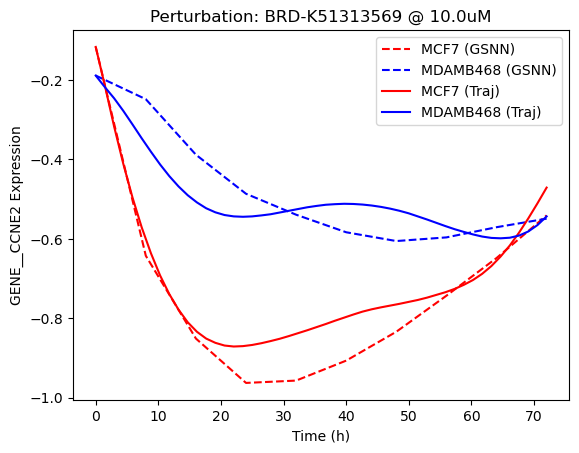

In [17]:
plt.figure()
plt.plot(np.linspace(0,t.max().item(), x1_t_hat.shape[0]), x1_t_hat[:, target_ix].detach().cpu().numpy(), 'r--', label=f'{cell1} (GSNN)')
plt.plot(np.linspace(0,t.max().item(), x2_t_hat.shape[0]), x2_t_hat[:, target_ix].detach().cpu().numpy(), 'b--', label=f'{cell2} (GSNN)')
plt.plot(np.linspace(0,t.max().item(), x1.shape[0]), x1[:, target_ix].detach().cpu().numpy(), 'r-', label=f'{cell1} (Traj)')
plt.plot(np.linspace(0,t.max().item(), x2.shape[0]), x2[:, target_ix].detach().cpu().numpy(), 'b-', label=f'{cell2} (Traj)')
plt.title(f'Perturbation: {drug} @ {dose}uM')
plt.xlabel('Time (h)')
plt.ylabel(f'{target_gene} Expression')
plt.legend()
plt.show()

In [18]:
ode_params = {'t': t, 
              'method': 'euler', 
              'tol': None} 


gsnn_explainer_params = {'hard': False, 
                         'beta': 5e-4, 
                         'lr': 5e-2, 
                         'prior': 5, 
                         'iters': 250, 
                         'entropy': 1., 
                         'grad_norm_clip': 1.0, 
                         'free_edges': 100} 


# CELL1 explanation

In [19]:

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)

explainer = GSNNExplainer(ode_gsnn, 
                          data, 
                          **gsnn_explainer_params)

gsnn_res1 = explainer.explain(x0_1.to(device), target_idx=[target_ix], target='edge')

iter: 249 | loss: 1.0770 | mse: 0.0108 | r2: 0.817 | active edges: 1964 / 43637 | entropy: 0.133689
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 689 / 43637 (1.6%)
MSE (subset): 0.005762
R² (subset): 0.9019
Variance explained: 0.9660
Correlation: 0.9828


In [20]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(x1_t_hat_input.to(device), 
                                   target_idx=target_ix, 
                                   target='edge', 
                                   element_mask=gsnn_res1.score.values > 0.5) 


In [21]:
#explainer = NoiseTunnel(IGExplainer(model.to(device), data), n_samples=10, noise_std=0.1) 
explainer = IGExplainer(model.to(device), data)
ig_res1 = explainer.explain(x1_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='edge', 
                            reduction='sum',
                            element_mask=gsnn_res1.score.values > 0.5)

In [22]:

res1 = gsnn_res1.merge(ig_res1, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res1 = res1.merge(occlusion_res1, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res1 = res1.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
res1 = res1[lambda x: x.gsnn_score > 0.5]
#res1 = res1[lambda x: x.occlusion_score.abs() > 0.05]
print(res1.shape)
res1.head(25)

(689, 7)


,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
73,RNA__hsa-miR-24-3p,RNA__E2F2,0.938598,-5.454766e-06,1.439452e-06,5.454766e-06,1.439452e-06
103,RNA__CREB1,PROTEIN__CREB1,0.978856,-3.153428e-01,-3.879749e-03,3.153428e-01,3.879749e-03
166,PROTEIN__CCNA1,PROTEIN__E2F1,0.998355,8.306679e-02,3.403531e-01,8.306679e-02,3.403531e-01
251,PROTEIN__SOX2,RNA__hsa-miR-200c,0.995154,5.183256e-02,-3.845734e-02,5.183256e-02,3.845734e-02
494,PROTEIN__GATA2,RNA__hsa-miR-31*,0.704802,-3.545873e-07,-8.437783e-07,3.545873e-07,8.437783e-07
529,RNA__CAPN1,PROTEIN__CAPN1,0.916050,3.216069e-02,-1.523862e-02,3.216069e-02,1.523862e-02
553,PROTEIN__SMARCA4,PROTEIN__ZEB1,0.996600,-3.182707e-03,-1.170505e-01,3.182707e-03,1.170505e-01
690,RNA__hsa-miR-200c,RNA__CCNE2,0.999349,-1.553205e+00,-2.894680e-01,1.553205e+00,2.894680e-01
831,PROTEIN__SP1,RNA__hsa-miR-34c-5p,0.793891,4.009720e-02,2.512857e-02,4.009720e-02,2.512857e-02
856,PROTEIN__MEF2C,RNA__ETS1,0.985185,-5.266782e-07,-1.460314e-07,5.266782e-07,1.460314e-07


In [23]:
res1[['ig_score', 'occlusion_score', 'gsnn_score', 'abs_ig_score', 'abs_oc_score']].corr(method='spearman')

,ig_score,occlusion_score,gsnn_score,abs_ig_score,abs_oc_score
ig_score,1.000000,0.513632,-0.030630,0.002581,0.041973
occlusion_score,0.513632,1.000000,-0.023045,-0.023692,-0.068668
gsnn_score,-0.030630,-0.023045,1.000000,0.380756,0.366985
abs_ig_score,0.002581,-0.023692,0.380756,1.000000,0.784372
abs_oc_score,0.041973,-0.068668,0.366985,0.784372,1.000000


In [24]:
res1.shape

(689, 7)

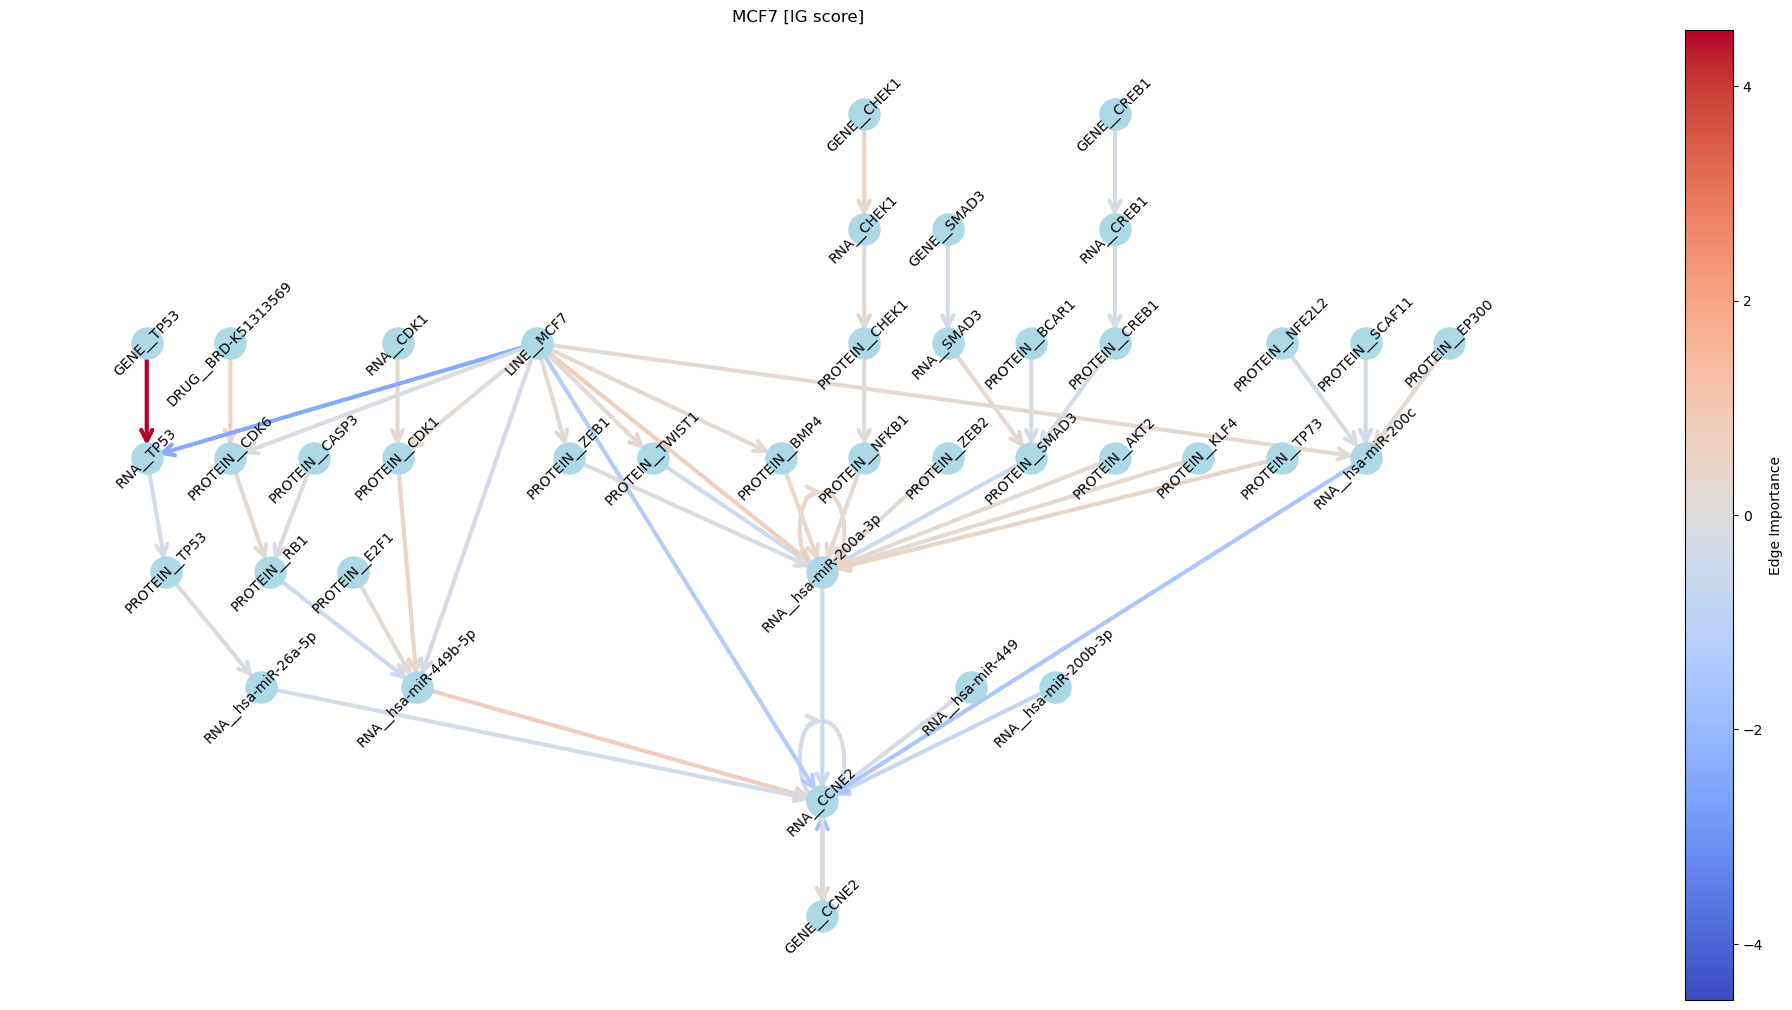

In [25]:
plot_edge_importance(res1.rename(columns={'ig_score': 'score'}).sort_values(by='abs_ig_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} [IG score]')

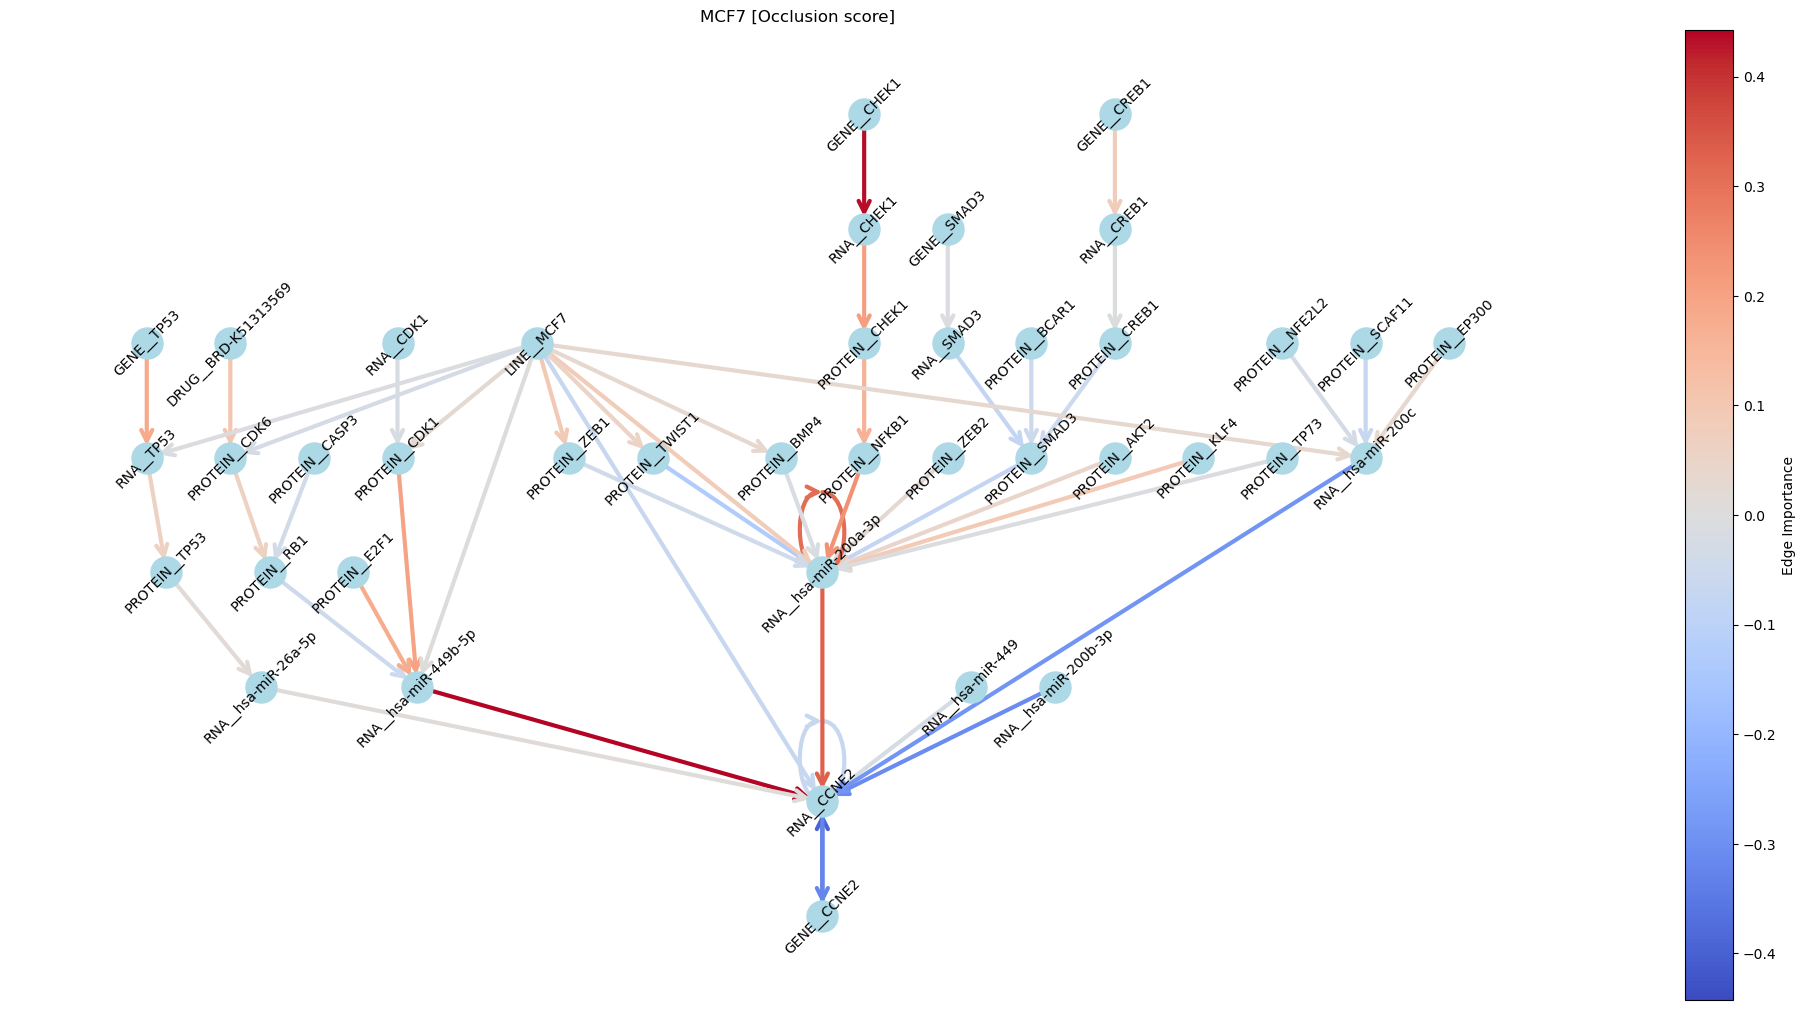

In [26]:
plot_edge_importance(res1.rename(columns={'occlusion_score': 'score'}).sort_values(by='abs_ig_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell1} [Occlusion score]')

In [27]:
G = nx.from_pandas_edgelist(res1, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(gsnn_res1, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr1 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr1.res2d.sort_values(by='Adjusted P-value', ascending=True).head(20)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Cellular Senescence R-HSA-2559583,1.900870e-13
1,Generic Transcription Pathway R-HSA-212436,6.811708e-12
2,RNA Polymerase II Transcription R-HSA-73857,6.681463e-11
3,Gene Expression (Transcription) R-HSA-74160,1.658098e-10
4,Oncogene Induced Senescence R-HSA-2559585,1.683007e-08
5,Oxidative Stress Induced Senescence R-HSA-2559580,2.143707e-08
6,Senescence-Associated Secretory Phenotype (SAS...,2.605002e-08
8,Signaling By Nuclear Receptors R-HSA-9006931,1.152850e-07
9,MyD88-independent TLR4 Cascade R-HSA-166166,1.152850e-07
7,Developmental Biology R-HSA-1266738,1.152850e-07


In [28]:
# we expect MCF7 to RB1 proficent and therefore involved 
# we expect MDAMB231 to have be RB1 deficient and therefore uninvolved, what is the RB1 scores? 


res1_all = gsnn_res1.merge(ig_res1, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res1_all = res1_all.merge(occlusion_res1, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res1_all = res1_all.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs()) 

res1_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5]

,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
2622,PROTEIN__RB1,RNA__hsa-miR-449b-5p,0.997388,-0.560748,-5.038348e-02,0.560748,5.038348e-02
17524,GENE__RB1,RNA__RB1,0.996016,-0.202491,-1.538701e-02,0.202491,1.538701e-02
14757,PROTEIN__CDK6,PROTEIN__RB1,0.986893,0.212540,6.532153e-02,0.212540,6.532153e-02
5977,PROTEIN__CASP3,PROTEIN__RB1,0.984853,-0.199302,-3.628311e-02,0.199302,3.628311e-02
28724,LINE__MCF7,PROTEIN__RB1,0.971572,-0.037166,-2.787039e-02,0.037166,2.787039e-02
40589,RNA__RB1,GENE__RB1,0.966855,0.000000,-2.682209e-08,0.000000,2.682209e-08
981,PROTEIN__CHEK1,PROTEIN__RB1,0.928587,-0.109168,-2.069307e-02,0.109168,2.069307e-02
2621,PROTEIN__RB1,RNA__hsa-miR-449,0.801347,-0.062128,3.637081e-03,0.062128,3.637081e-03


In [29]:
res1_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].ig_score.sum()

np.float32(-0.95846367)

In [30]:
res1_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].occlusion_score.sum()

np.float64(-0.08165848283097077)

In [31]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res1 = explainer.explain(x0_1.to(device), 
                                   target_idx=target_ix, 
                                   target='node')

occlusion_res1.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__RB1')].head().style.hide()

node,score
RNA__RB1,0.021507
PROTEIN__RB1CC1,0.000545
GENE__RB1,0.000000
GENE__RB1,0.000000
PROTEIN__RB1,-0.014987


In [32]:
explainer = IGExplainer(model.to(device), data)
ig_res1 = explainer.explain(x1_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='node', 
                            reduction='sum')

ig_res1.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__RB1')].head().style.hide()

node,score
PROTEIN__RB1CC1,0.001595
GENE__RB1,0.000000
GENE__RB1,0.000000
RNA__RB1,-0.044098
PROTEIN__RB1,-0.219368


# CELL 2 Explanation 

In [33]:

ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)

explainer = GSNNExplainer(ode_gsnn, 
                          data, 
                          **gsnn_explainer_params)

gsnn_res2 = explainer.explain(x0_2.to(device), target_idx=[target_ix], target='edge')

iter: 249 | loss: 0.9157 | mse: 0.0058 | r2: 0.713 | active edges: 1664 / 43637 | entropy: 0.1318050
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 345 / 43637 (0.8%)
MSE (subset): 0.020342
R² (subset): -0.0010
Variance explained: 0.9079
Correlation: 0.9528


In [34]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(x2_t_hat_input.to(device), 
                                   target_idx=target_ix, 
                                   target='edge', 
                                   element_mask=gsnn_res2.score.values > 0.5) 


In [35]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='edge', 
                            reduction='sum',
                            element_mask=gsnn_res2.score.values > 0.5)

In [36]:
res2 = gsnn_res2.merge(ig_res2, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res2 = res2.merge(occlusion_res2, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res2 = res2.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
res2 = res2[lambda x: x.gsnn_score > 0.5]
print(res2.shape)
res2.head()

(345, 7)


,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
103,RNA__CREB1,PROTEIN__CREB1,0.950328,-0.111869,0.009837,0.111869,0.009837
166,PROTEIN__CCNA1,PROTEIN__E2F1,0.876882,0.212264,0.268626,0.212264,0.268626
213,PROTEIN__TLR4,PROTEIN__MAPK14,0.885511,-0.079220,0.013259,0.079220,0.013259
251,PROTEIN__SOX2,RNA__hsa-miR-200c,0.992549,0.286275,0.022966,0.286275,0.022966
430,PROTEIN__GATA2,RNA__CAPN1,0.936915,0.000014,0.000004,0.000014,0.000004


In [37]:
res2[['ig_score', 'occlusion_score', 'gsnn_score', 'abs_ig_score', 'abs_oc_score']].corr(method='spearman')

,ig_score,occlusion_score,gsnn_score,abs_ig_score,abs_oc_score
ig_score,1.000000,0.605189,-0.080949,-0.000280,0.039780
occlusion_score,0.605189,1.000000,0.007113,0.010101,-0.014662
gsnn_score,-0.080949,0.007113,1.000000,0.455025,0.403005
abs_ig_score,-0.000280,0.010101,0.455025,1.000000,0.758060
abs_oc_score,0.039780,-0.014662,0.403005,0.758060,1.000000


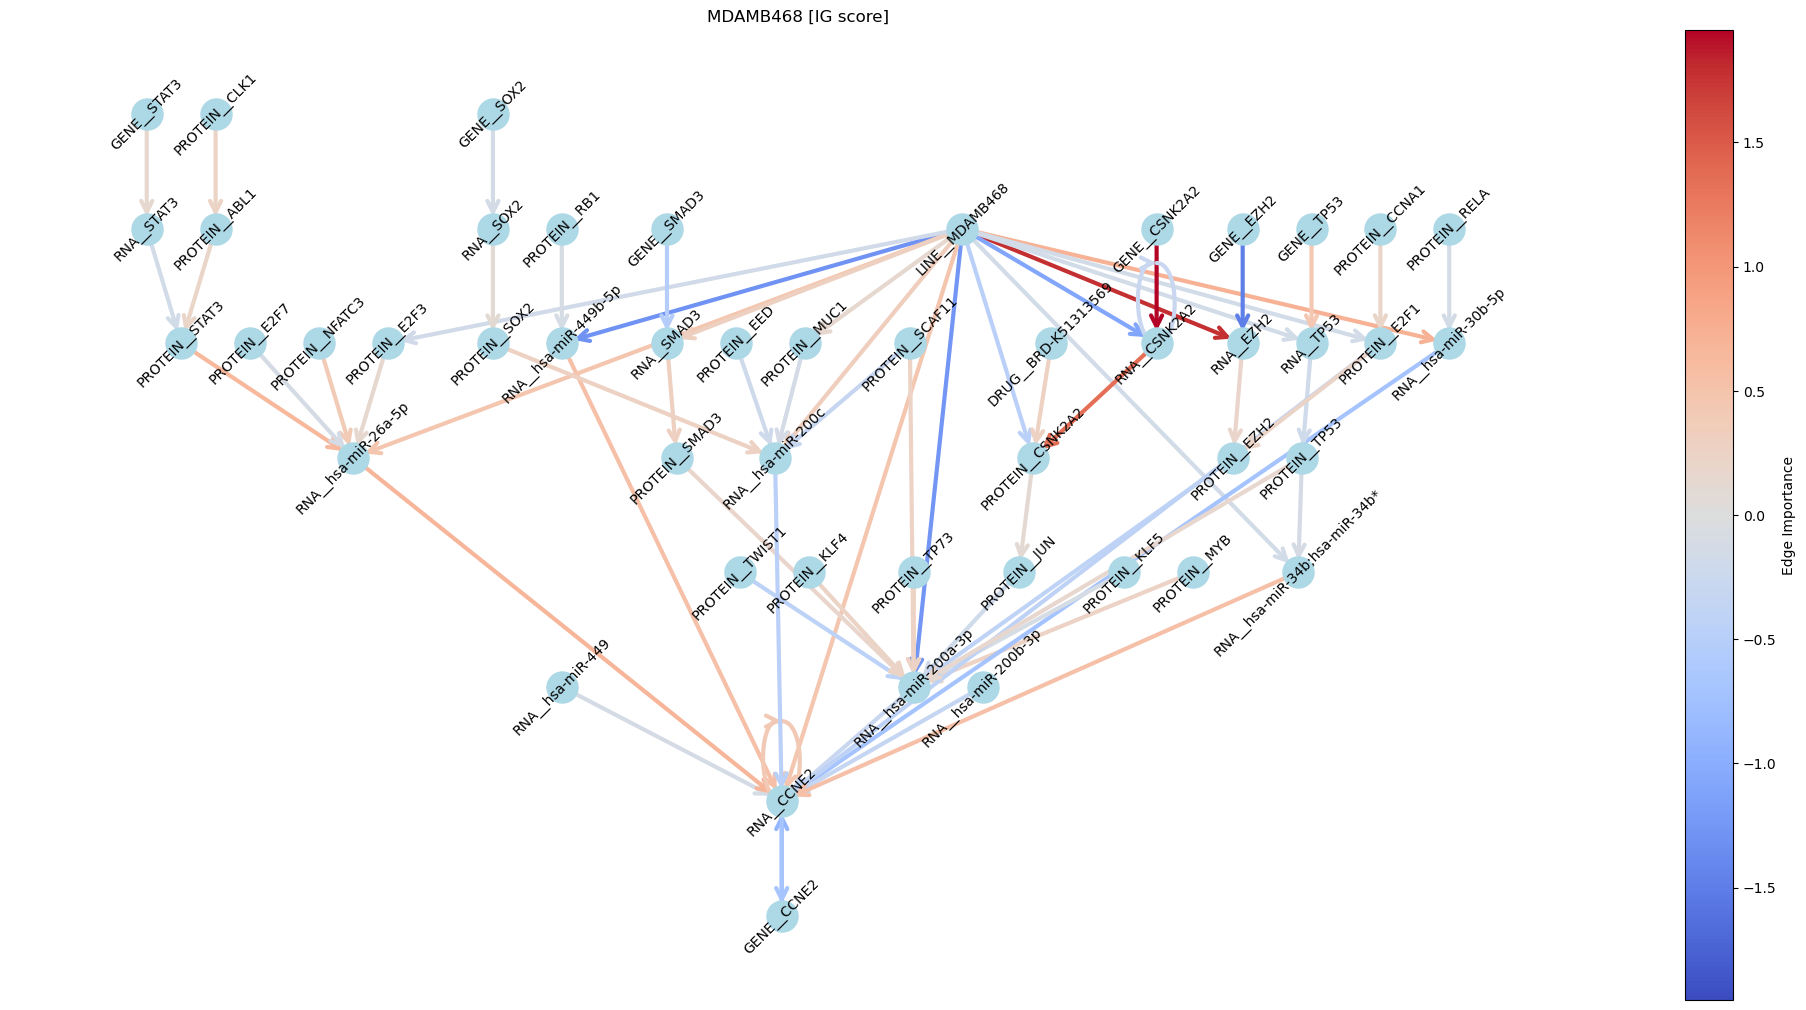

In [38]:
plot_edge_importance(res2.rename(columns={'ig_score': 'score'}).sort_values(
                            by='abs_ig_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [IG score]')

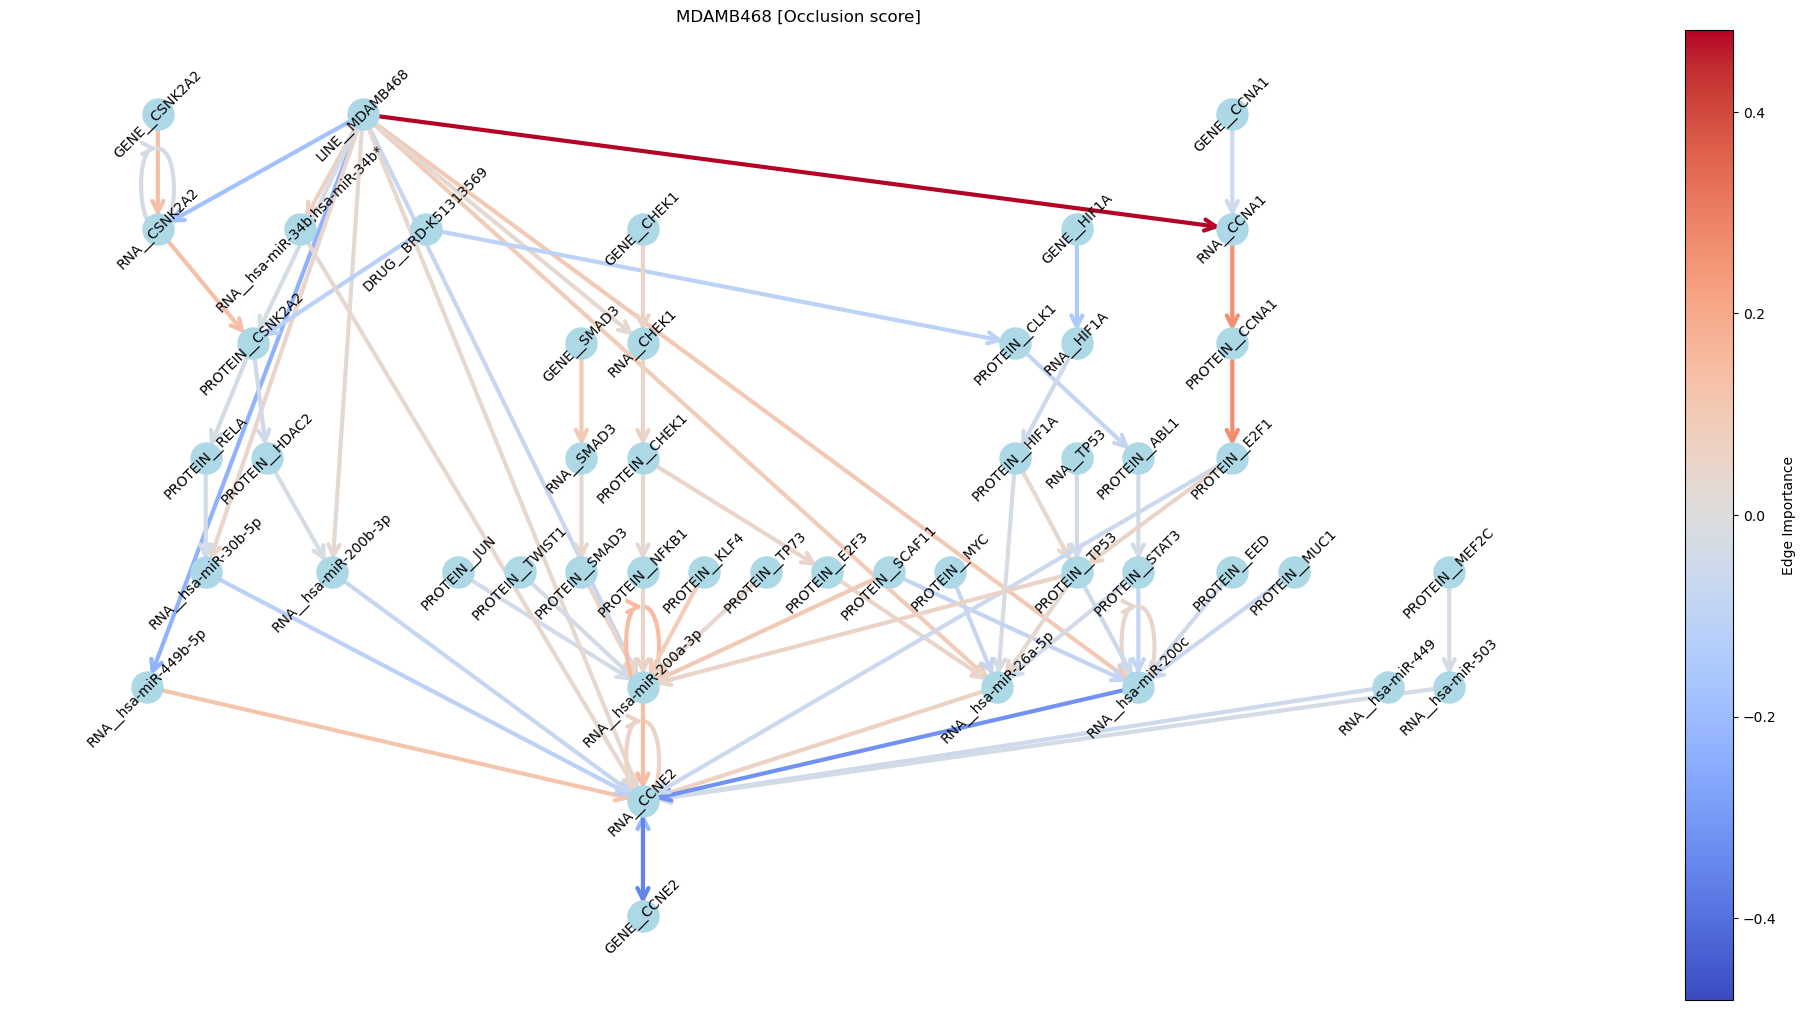

In [39]:
plot_edge_importance(res2.rename(columns={'occlusion_score': 'score'}).sort_values(
                            by='abs_oc_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [Occlusion score]')

In [40]:
G = nx.from_pandas_edgelist(res2, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(gsnn_res2, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr2 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr2.res2d.sort_values(by='Adjusted P-value', ascending=True).head(20)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Cellular Senescence R-HSA-2559583,1.233088e-18
1,Generic Transcription Pathway R-HSA-212436,1.589615e-16
2,RNA Polymerase II Transcription R-HSA-73857,1.339349e-15
3,Gene Expression (Transcription) R-HSA-74160,5.844936e-15
4,Cellular Responses To Stress R-HSA-2262752,1.736652e-13
5,Cellular Responses To Stimuli R-HSA-8953897,2.792900e-13
6,Disease R-HSA-1643685,4.913030e-13
7,Developmental Biology R-HSA-1266738,2.650799e-12
8,Signaling By Interleukins R-HSA-449147,6.766947e-12
9,Cytokine Signaling In Immune System R-HSA-1280215,8.090779e-12


In [41]:
# we expect MDAMB231 to have be RB1 deficient and therefore uninvolved, what is the RB1 scores? 

res2_all = gsnn_res2.merge(ig_res2, on=['source', 'target'], how='inner').rename(columns={'score_x': 'gsnn_score', 'score_y': 'ig_score'})
res2_all = res2_all.merge(occlusion_res2, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
res2_all = res2_all.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs()) 


res2_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5]

,source,target,gsnn_score,ig_score,occlusion_score,abs_ig_score,abs_oc_score
17524,GENE__RB1,RNA__RB1,0.993600,0.054221,-0.105620,0.054221,0.105620
33597,LINE__MDAMB468,RNA__RB1,0.962163,-0.029028,-0.020006,0.029028,0.020006
2622,PROTEIN__RB1,RNA__hsa-miR-449b-5p,0.548939,-0.102144,-0.013756,0.102144,0.013756


In [42]:
res2_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].ig_score.sum()

np.float32(-0.07695056)

In [43]:
res2_all[lambda x: x.source.str.contains(f'RB1') | x.target.str.contains(f'RB1')].sort_values(by='gsnn_score', ascending=False)[lambda x: x.gsnn_score > 0.5].occlusion_score.sum()

np.float64(-0.13938117492944002)

In [44]:
explainer = OcclusionExplainer(model.to(device), data)
occlusion_res2 = explainer.explain(x0_2.to(device), 
                                   target_idx=target_ix, 
                                   target='node')

occlusion_res2.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__RB1')].head().style.hide()

node,score
RNA__RB1,0.068381
PROTEIN__RB1CC1,0.000308
GENE__RB1,-0.000000
GENE__RB1,-0.000000
PROTEIN__RB1,-0.029461


In [45]:
explainer = IGExplainer(model.to(device), data)
ig_res2 = explainer.explain(x0_2.to(device), 
                            target_idx=target_ix, 
                            target='node', 
                            reduction='sum')

ig_res2.sort_values(by='score', ascending=False)[lambda x: x.node.str.contains(f'__RB1')].head().style.hide()

node,score
RNA__RB1,0.016276
PROTEIN__RB1CC1,0.000034
GENE__RB1,0.000000
GENE__RB1,0.000000
PROTEIN__RB1,-0.011669


# comparing GSEA results between CELL 1 and CELL 2 

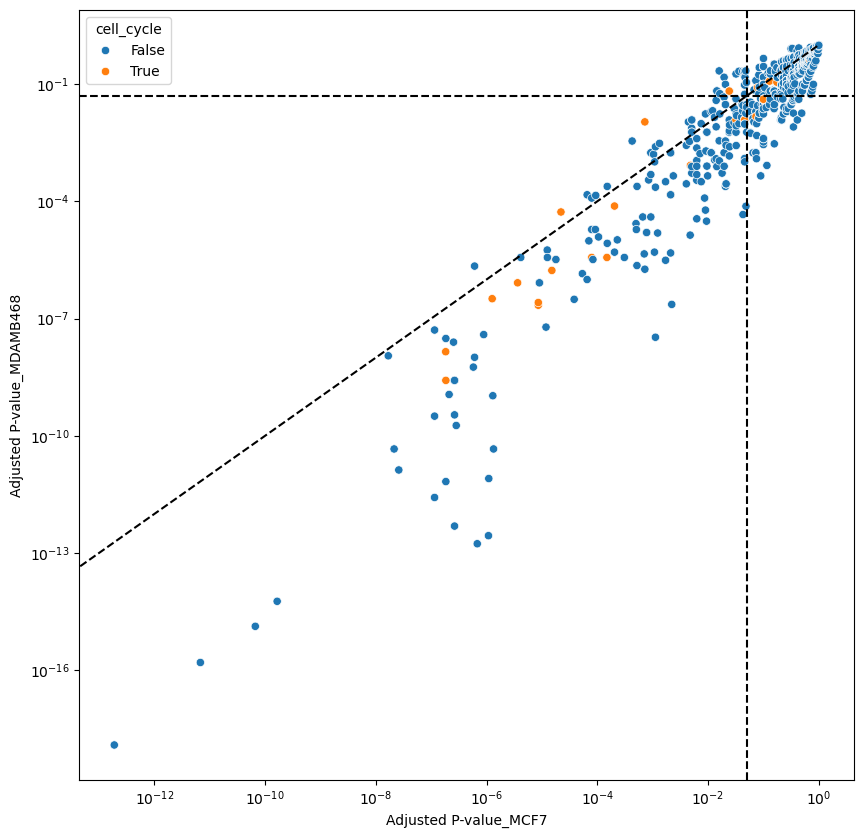

In [46]:
enr = enr1.res2d.merge(enr2.res2d, on='Term', how='inner')
enr = enr.rename(columns={'Adjusted P-value_x': f'Adjusted P-value_{cell1}', 'Adjusted P-value_y': f'Adjusted P-value_{cell2}'})
enr = enr.assign(cell_cycle = lambda x: x.Term.str.lower().str.contains('cell cycle') | x.Term.str.contains('G1'))

plt.figure(figsize=(10, 10))
sbn.scatterplot(data=enr, x=f'Adjusted P-value_{cell1}', y=f'Adjusted P-value_{cell2}', hue='cell_cycle')
plt.plot([0, 1], [0, 1], 'k--')
plt.xscale('log')
plt.yscale('log')

plt.axvline(0.05, color='k', linestyle='--')
plt.axhline(0.05, color='k', linestyle='--')


# add text labels to outliers (those that are not similar between the two cells)
'''for i, row in enr.iterrows():
    cell1_log_pval = np.log10(row[f'Adjusted P-value_{cell1}'])
    cell2_log_pval = np.log10(row[f'Adjusted P-value_{cell2}'])
    diff = np.abs(cell1_log_pval - cell2_log_pval)
    if diff > 2.5:
        plt.text(row[f'Adjusted P-value_{cell1}'], row[f'Adjusted P-value_{cell2}'], row['Term'], fontsize=12)'''

plt.show()

# Contrastive Explanation 

In [47]:
ode_gsnn = ODEWrapper(model, 
                      data, 
                      dxdt_scale, 
                      **ode_params)
                      

explainer = ContrastiveGSNNExplainer(ode_gsnn, 
                                     data,
                                     hard=False,
                                     beta=5e-4,
                                     lr=1e-1,
                                     prior=5,
                                     iters=250,
                                     free_edges=100)

                                     
cres_gsnn = explainer.explain(x0_1.to(device), 
                              x0_2.to(device), 
                              target_idx=target_ix, 
                              target='edge')

cres_gsnn.head()

Batch size: 1, Target dims: 1
Target Δf mean: -0.244683, std: 0.200475
iter: 249 | loss: 0.9788 | mse: 0.0070 | r2: 0.806 | active edges: 1511 / 43637 | entropy: 0.126505
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 346 / 43637 (0.8%)
Target Δf mean: -0.244683
Subset Δf mean: -0.209360
MSE: 0.005091
R² (across 1x1 elements): 0.8592


,source,target,score
0,PROTEIN__IL4R,PROTEIN__JAK1,0.028693
1,PROTEIN__IL4R,PROTEIN__JAK3,0.013142
2,PROTEIN__IL4R,PROTEIN__JAK2,0.020425
3,PROTEIN__IL4R,PROTEIN__STAT5A,0.028380
4,RNA__hsa-let-7c-3p,RNA__HMGA2,0.029406


In [50]:
explainer = ContrastiveIGExplainer(model.to(device), data)

cres_ig = explainer.explain(x1_t_hat_input.to(device), 
                            x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            element_mask=cres_gsnn.score.values > 0.5,
                            target='edge')

cres_ig.sort_values(by='score', ascending=False).head()


,source,target,score
40727,RNA__CCNE2,GENE__CCNE2,0.387256
16671,GENE__TP53,RNA__TP53,0.256202
34113,LINE__MDAMB468,RNA__hsa-miR-449b-5p,0.152609
16485,GENE__PAK1,RNA__PAK1,0.133123
29286,LINE__MCF7,RNA__JUN,0.111357


In [51]:

explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(x1_t_hat_input.to(device), 
                             x2_t_hat_input.to(device), 
                             target_idx=target_ix, 
                             element_mask=cres_gsnn.score.values > 0.5,
                             target='edge')

cres_occ.head()

,source,target,score
0,PROTEIN__IL4R,PROTEIN__JAK1,NaN
1,PROTEIN__IL4R,PROTEIN__JAK3,NaN
2,PROTEIN__IL4R,PROTEIN__JAK2,NaN
3,PROTEIN__IL4R,PROTEIN__STAT5A,NaN
4,RNA__hsa-let-7c-3p,RNA__HMGA2,NaN


In [54]:
cres = cres_ig.merge(cres_gsnn, on=['source', 'target'], how='inner').rename(columns={'score_x': 'ig_score', 'score_y': 'gsnn_score'})
cres = cres.merge(cres_occ, on=['source', 'target'], how='left').rename(columns={'score': 'occlusion_score'})
cres = cres.assign(abs_ig_score = lambda x: x.ig_score.abs(),
                   abs_oc_score = lambda x: x.occlusion_score.abs())
cres = cres[lambda x: x.gsnn_score > 0.5]
cres.head() 

,source,target,ig_score,gsnn_score,occlusion_score,abs_ig_score,abs_oc_score
166,PROTEIN__CCNA1,PROTEIN__E2F1,0.026788,0.999756,-0.026632,0.026788,0.026632
251,PROTEIN__SOX2,RNA__hsa-miR-200c,0.012807,0.980444,0.051084,0.012807,0.051084
690,RNA__hsa-miR-200c,RNA__CCNE2,0.091790,0.868108,-0.051445,0.091790,0.051445
865,PROTEIN__MEF2C,RNA__hsa-miR-503,0.005183,0.836280,0.036286,0.005183,0.036286
975,PROTEIN__CHEK1,PROTEIN__E2F7,0.008607,0.787579,0.009199,0.008607,0.009199


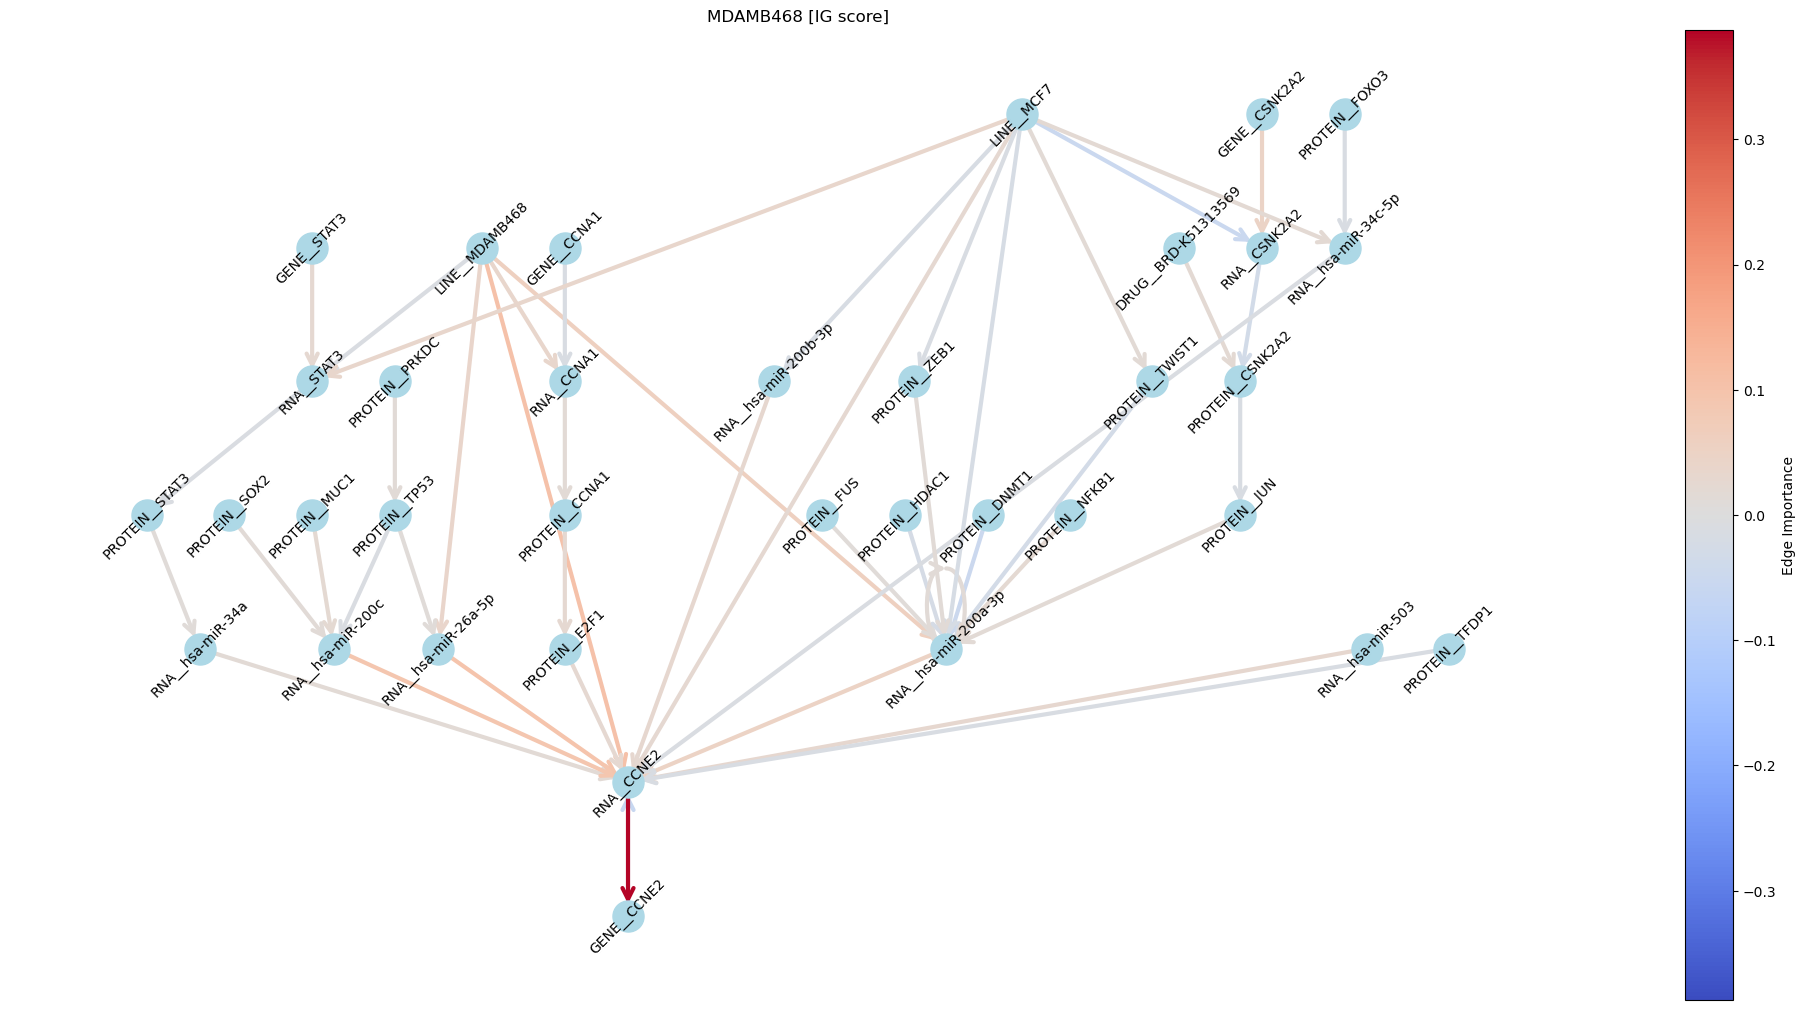

In [55]:
plot_edge_importance(cres.rename(columns={'ig_score': 'score'}).sort_values(
                            by='abs_ig_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [IG score]')

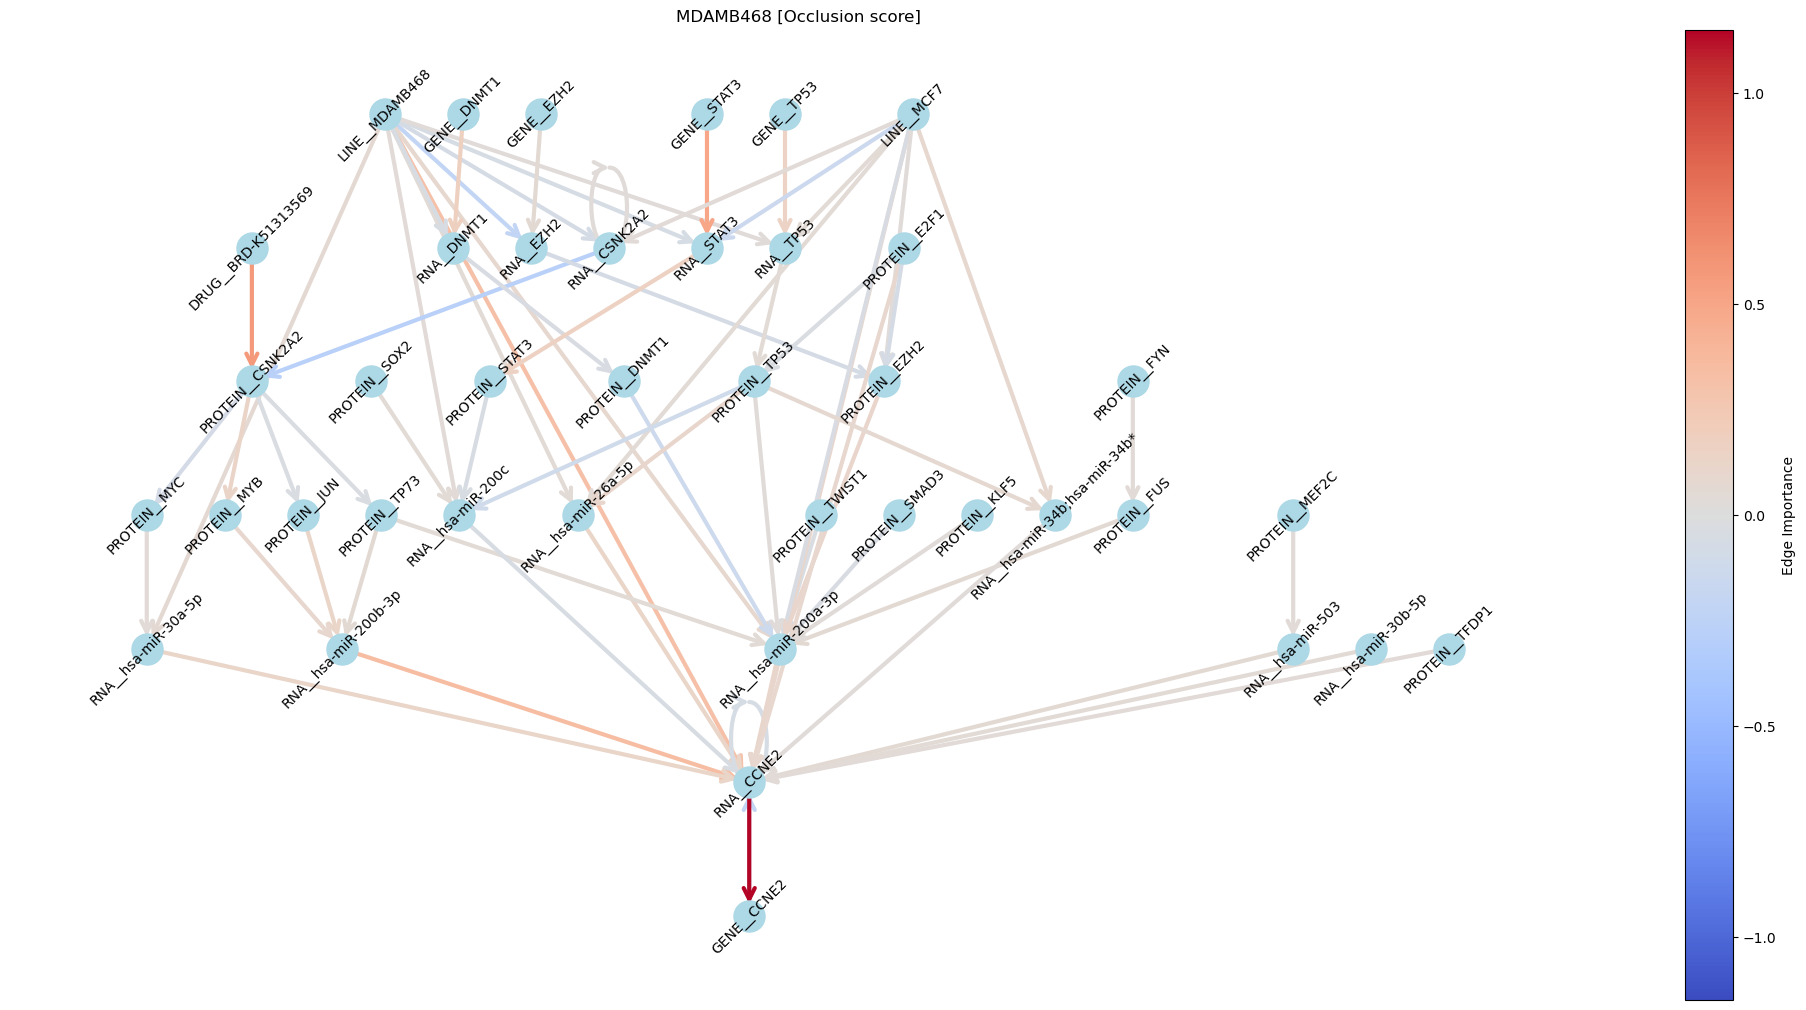

In [56]:
plot_edge_importance(cres.rename(columns={'occlusion_score': 'score'}).sort_values(
                            by='abs_oc_score', ascending=False).head(150), 
                     figsize=(20,10), 
                     leafs=[target_gene], 
                     title=f'{cell2} [Occlusion score]')

In [57]:
G = nx.from_pandas_edgelist(cres, source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(cres_gsnn, source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr1 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr1.res2d.sort_values(by='Adjusted P-value', ascending=True).head(20)[['Term', 'Adjusted P-value']].style.hide()

Term,Adjusted P-value
Cellular Senescence R-HSA-2559583,0.000000
Generic Transcription Pathway R-HSA-212436,0.000000
RNA Polymerase II Transcription R-HSA-73857,0.000000
Gene Expression (Transcription) R-HSA-74160,0.000000
Disease R-HSA-1643685,0.000000
Cellular Responses To Stress R-HSA-2262752,0.000000
Cellular Responses To Stimuli R-HSA-8953897,0.000000
Developmental Biology R-HSA-1266738,0.000000
Signaling By Interleukins R-HSA-449147,0.000000
Oxidative Stress Induced Senescence R-HSA-2559580,0.000000


In [63]:
explainer = ContrastiveIGExplainer(model.to(device), data)

cres_ig = explainer.explain(x1_t_hat_input.to(device), 
                            x2_t_hat_input.to(device), 
                            target_idx=target_ix, 
                            target='node')

#cres_ig[lambda x: x.node.str.contains(f'__RB1')].sort_values(by='score', ascending=False).head()
cres_ig.sort_values(by='score', ascending=False).head(25)


,node,score
886,RNA__CCNE2,0.583119
275,RNA__hsa-miR-449b-5p,0.105926
1512,RNA__hsa-miR-26a-5p,0.093468
552,PROTEIN__STAT3,0.080462
814,PROTEIN__EZH2,0.075112
1476,RNA__hsa-miR-200b-3p,0.060787
475,RNA__hsa-miR-200a-3p,0.054002
1705,PROTEIN__JUN,0.043912
1916,PROTEIN__GATA3,0.034597
496,RNA__STAT3,0.032569


In [59]:
cres_ig.sort_values(by='score', ascending=False).tail()

,node,score
722,PROTEIN__EGR1,-0.037199
1225,RNA__hsa-miR-449,-0.045154
1824,PROTEIN__AKT1,-0.048034
2018,PROTEIN__DNMT1,-0.049944
303,RNA__CSNK2A2,-0.064189


In [60]:
explainer = ContrastiveOcclusionExplainer(model.to(device), data)
cres_occ = explainer.explain(x1_t_hat_input.to(device), 
                             x2_t_hat_input.to(device), 
                             target_idx=target_ix, 
                             target='node')

cres_occ.sort_values(by='score', ascending=False).head().style.hide()

node,score
RNA__CCNE2,1.149873
PROTEIN__CSNK2A2,0.341872
RNA__hsa-miR-200b-3p,0.340839
RNA__hsa-miR-449b-5p,0.307241
PROTEIN__TP53,0.206165


In [61]:
cres_occ.sort_values(by='score', ascending=False).tail()

,node,score
2018,PROTEIN__DNMT1,-0.126603
750,RNA__AKT1,-0.131799
1824,PROTEIN__AKT1,-0.132490
589,PROTEIN__FOXO3,-0.138533
303,RNA__CSNK2A2,-0.283885


In [62]:
G = nx.from_pandas_edgelist(cres[lambda x: x.gsnn_score > 0.5],
                            source='source', 
                            target='target', 
                            create_using=nx.DiGraph, 
                            edge_attr='ig_score')

centrality = nx.betweenness_centrality(G)
centrality = pd.Series(centrality, index=G.nodes())

centrality.sort_values(ascending=False).head(25)

PROTEIN__E2F1           0.010627
PROTEIN__TP53           0.010436
RNA__CCNA1              0.007766
PROTEIN__CCNA1          0.007460
RNA__CASP3              0.003832
PROTEIN__CSNK2A2        0.003637
PROTEIN__MYB            0.003627
PROTEIN__RELA           0.002984
PROTEIN__CASP3          0.002935
RNA__hsa-miR-200b-3p    0.002583
RNA__CCNE2              0.001814
RNA__hsa-miR-20a-3p     0.001773
PROTEIN__CDK1           0.001720
PROTEIN__GSK3B          0.001549
RNA__CSNK2A2            0.001437
RNA__E2F2               0.001345
RNA__EZH2               0.001141
RNA__TP53               0.000958
RNA__hsa-miR-200a-3p    0.000944
RNA__CREB1              0.000713
RNA__hsa-miR-372-3p     0.000713
RNA__hsa-miR-150        0.000670
RNA__NFATC3             0.000591
RNA__EGR1               0.000571
PROTEIN__HDAC2          0.000556
dtype: float64